# Milestone 2: Detection Dataset Construction

This notebook builds the synthetic multi-celebrity detection dataset used to fine-tune YOLOv8 in Milestone 3. CelebA only provides single-face photos, so we create synthetic "group photos" by pasting face crops of our four celebrities onto photos of empty rooms, and label every face with a YOLO-format bounding box.

The reusable logic lives in `src/synthesize.py`; this notebook calls those functions step by step and shows the results inline.


#### 0. Environment setup (local Jupyter or Google Colab)
On **Colab**: `Runtime -> Change runtime type -> T4 GPU` (CPU also works), then run this cell. By default it mounts Google Drive and uses (or clones) the repo at `MyDrive/IE7615-Group3-Project1`. Cloning the private repo needs a GitHub personal access token saved as a Colab secret named `GITHUB_TOKEN`. Locally, the cell just finds the repo root.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "preprocessing.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: /Users/pmodi/Desktop/P2/Rhea/NU Grad/IE 7615/Project 1/IE7615-Group3-Project1


In [2]:
import random

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

from src import synthesize as syn

print("Classes:", dict(enumerate(syn.CLASS_NAMES)))
display(pd.crosstab(syn.FACES["identity"], syn.FACES["split"])[["train", "val", "test"]])

Classes: {0: 'id_2336', 1: 'id_2970', 2: 'id_4422', 3: 'id_7007'}


split,train,val,test
identity,,,
2336,15,5,5
2970,15,5,5
4422,15,5,5
7007,14,5,5


---
## Task 1: Composition + Labels

Source faces are the 99 CelebA photos from Milestone 1, reused with the **same 60 / 20 / 20 per-identity split** (`data/splits.csv`). Every synthetic image draws its faces and its background from one split only, so no face or background appears in more than one of train, validation and test.

**YOLO folder structure**

YOLO expects `images/` and `labels/` folders for each split, with each image matched to a label file of the same name, plus a `data.yaml` listing the folders and class names. Class IDs match Milestone 1.

In [3]:
syn.setup_folders()
print((syn.DET_DIR / "data.yaml").read_text())

Created YOLO folders and data.yaml in /Users/pmodi/Desktop/P2/Rhea/NU Grad/IE 7615/Project 1/IE7615-Group3-Project1/data/detection
train: images/train
val: images/val
test: images/test
names:
  0: id_2336
  1: id_2970
  2: id_4422
  3: id_7007



**Part B: Face trimming**

Each CelebA photo (178 x 218) includes hair, neck and background. Before pasting, it is trimmed to the face region `FACE_BOX` (102 x 125), so the pasted patch is the face and its bounding box is tight. The green box below shows the trim region on 4 photos per identity.

FACE_BOX (left, top, right, bottom): (38, 60, 140, 185)
Saved /Users/pmodi/Desktop/P2/Rhea/NU Grad/IE 7615/Project 1/IE7615-Group3-Project1/results/milestone2/face_box_check.png


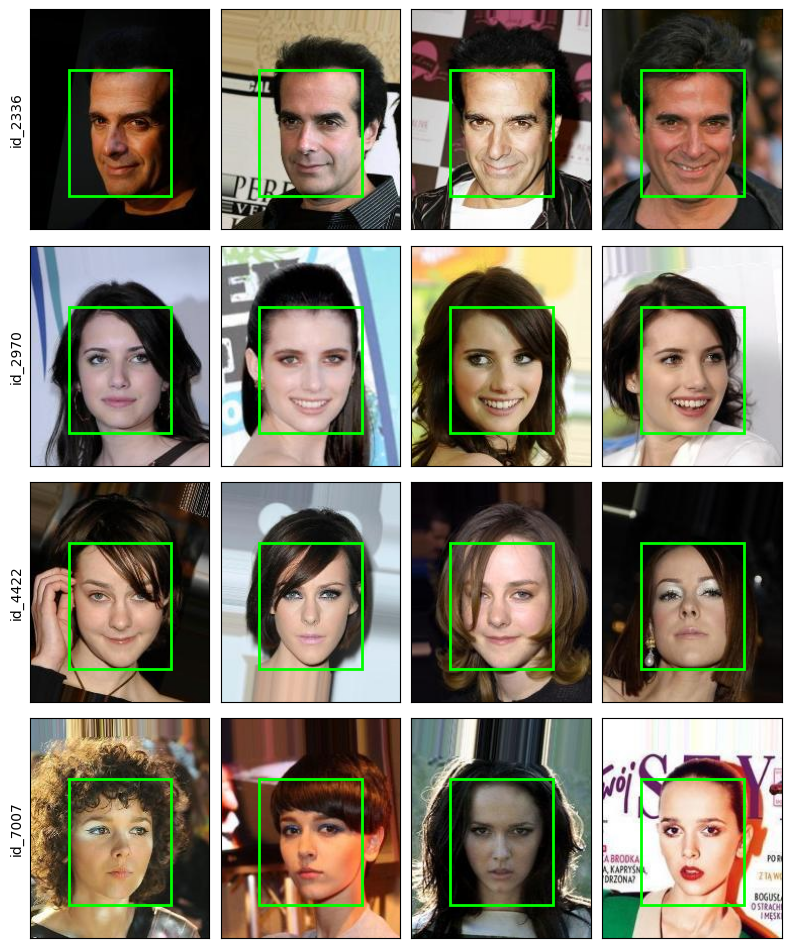

In [4]:
print("FACE_BOX (left, top, right, bottom):", syn.FACE_BOX)
syn.preview_face_box()
plt.show()

**Backgrounds**

30 openly licensed photos of empty rooms from Openverse (CC0, public domain, CC BY), resized to 640 x 640 and split 18 / 6 / 6, so test images use rooms never seen in training. No background contains a person, since an unlabelled face would teach the detector that faces are background. Sources and licenses: `data/backgrounds/SOURCES.md`.

{'train': 18, 'val': 6, 'test': 6}


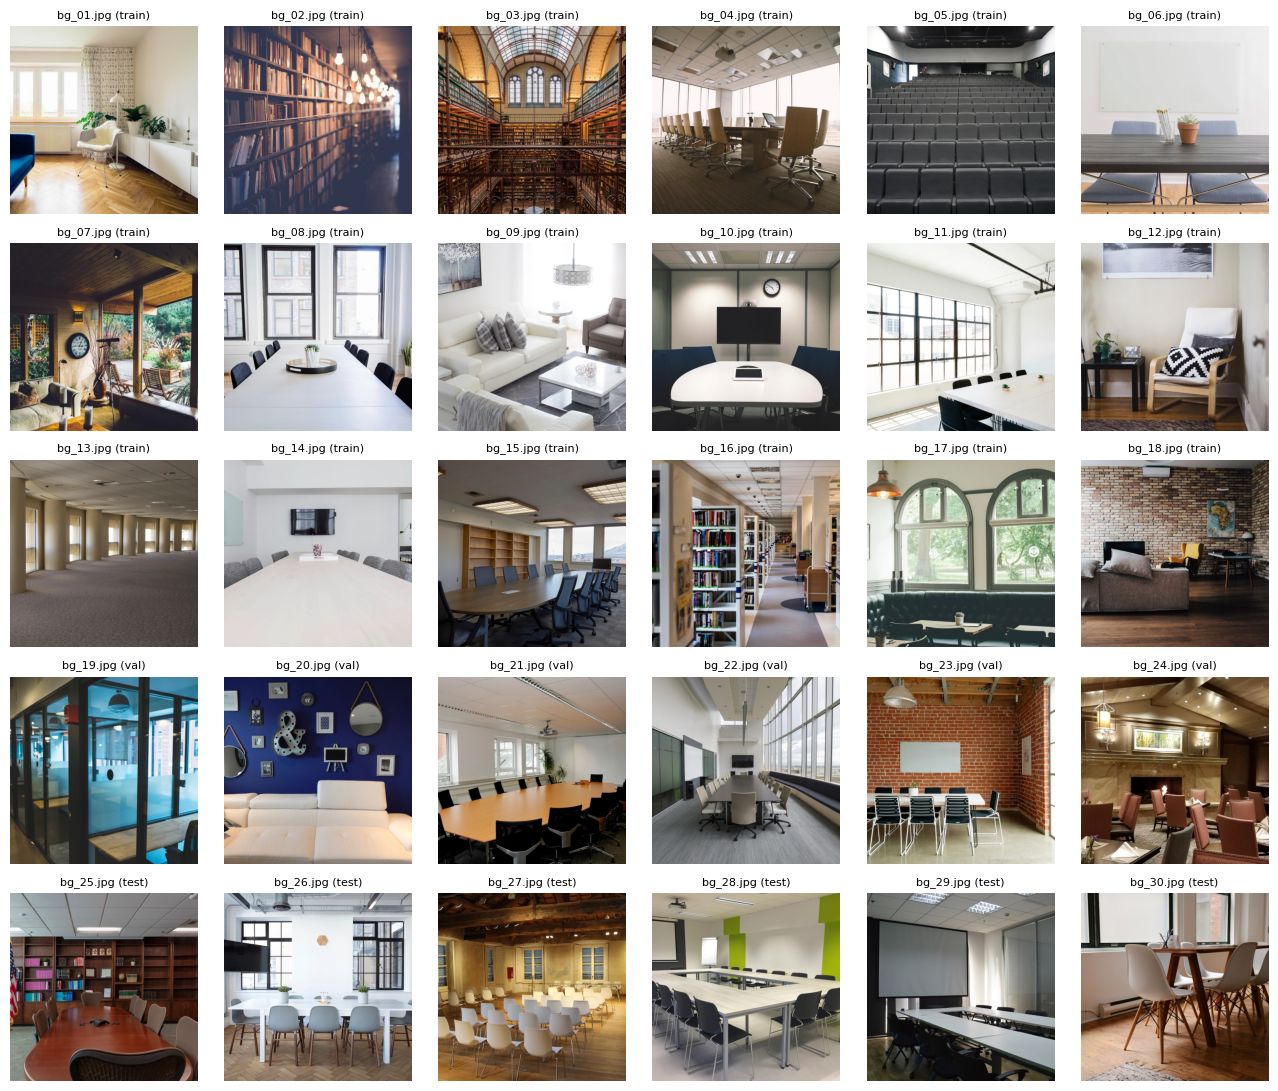

In [5]:
bg_files = [(s, f) for s in syn.SPLITS for f in sorted((syn.BG_DIR / s).glob("bg_*.jpg"))]
print(pd.Series([s for s, _ in bg_files]).value_counts()[list(syn.SPLITS)].to_dict())

fig, axes = plt.subplots(5, 6, figsize=(13, 11))
for ax in axes.flat:
    ax.axis("off")
for ax, (split, f) in zip(axes.flat, bg_files):
    ax.imshow(Image.open(f))
    ax.set_title(f"{f.name} ({split})", fontsize=8)
fig.tight_layout()
syn.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(syn.RESULTS_DIR / "backgrounds_contact_sheet.png", dpi=110, bbox_inches="tight")
plt.show()

**Composing a synthetic image**

`compose_image` pastes 2-4 **different** celebrities onto one background from the same split:
- random face height (`FACE_HEIGHT`) and brightness (`BRIGHTNESS`) for scale and lighting variation,
- random position within a head-height band (`HEAD_BAND`), with no overlapping faces,
- a soft oval blend, so faces don't come up as rectangular patches in the room.

It returns the image and each face's pixel box `(class_id, x1, y1, x2, y2)`.

Faces per image: (2, 4) | face height (px): (90, 220) | brightness: (0.7, 1.3) | head band: (0.2, 0.8)
Saved /Users/pmodi/Desktop/P2/Rhea/NU Grad/IE 7615/Project 1/IE7615-Group3-Project1/results/milestone2/composite_check_train.png


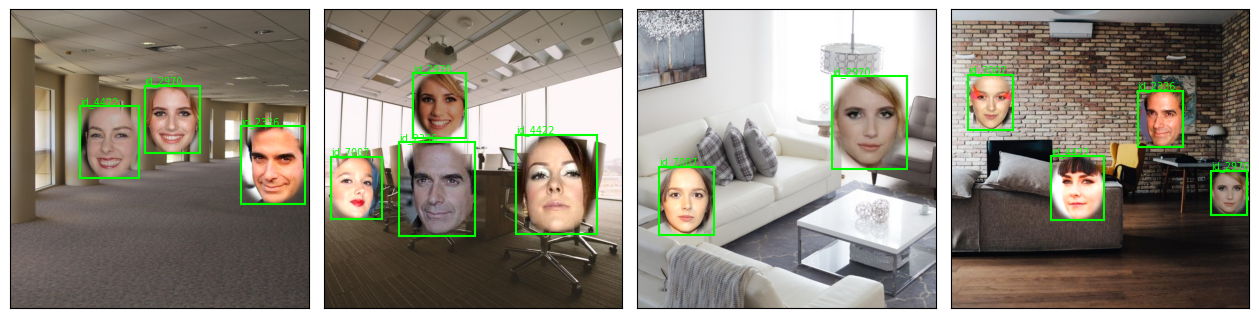

In [6]:
print("Faces per image:", syn.FACES_PER_IMAGE, "| face height (px):", syn.FACE_HEIGHT,
      "| brightness:", syn.BRIGHTNESS, "| head band:", syn.HEAD_BAND)
syn.preview_composites("train")
plt.show()

**YOLO labels**

YOLO describes each box by its center and size, divided by the image size so every value is between 0 and 1:
`class_id x_center y_center width height`. Below, one composed image's pixel boxes and the matching YOLO label lines.

In [7]:
image, boxes = syn.compose_image("train", random.Random(0))
print("Pixel boxes (class_id, x1, y1, x2, y2):")
for b in boxes:
    print(" ", b)
print("\nYOLO label lines:")
print("\n".join(syn.to_yolo(boxes)))

Pixel boxes (class_id, x1, y1, x2, y2):
  (0, 495, 250, 631, 417)
  (1, 288, 163, 406, 308)
  (2, 150, 207, 276, 361)

YOLO label lines:
0 0.879687 0.521094 0.212500 0.260937
1 0.542188 0.367969 0.184375 0.226562
2 0.332813 0.443750 0.196875 0.240625


**Generating the dataset**

300 / 100 / 100 images (60 / 20 / 20). Each split has its own fixed seed, so the dataset is fully reproducible and changing one split's size leaves the others unchanged. Files are named `<split>_<number>` (e.g. `train_0001.jpg` + `train_0001.txt`). Re-running this cell deletes the previous files first.

In [8]:
N_IMAGES = {"train": 300, "val": 100, "test": 100}
SEED = 42

rows = []
for i, (split, n) in enumerate(N_IMAGES.items()):
    rng = random.Random(SEED + i)
    img_dir = syn.DET_DIR / "images" / split
    lbl_dir = syn.DET_DIR / "labels" / split
    for old in [*img_dir.glob("*.jpg"), *lbl_dir.glob("*.txt")]:
        old.unlink()

    for k in range(1, n + 1):
        image, boxes = syn.compose_image(split, rng)
        name = f"{split}_{k:04d}"
        image.save(img_dir / f"{name}.jpg", quality=90)
        syn.write_label(boxes, lbl_dir / f"{name}.txt")
        rows += [{"split": split, "identity": syn.CLASS_NAMES[b[0]]} for b in boxes]

faces = pd.DataFrame(rows)
summary = pd.crosstab(faces["identity"], faces["split"], margins=True, margins_name="total")
summary = summary[["train", "val", "test", "total"]]
images_row = pd.DataFrame([{**N_IMAGES, "total": sum(N_IMAGES.values())}], index=["images"])
display(pd.concat([images_row, summary.rename(index={"total": "faces"})]))

,train,val,test,total
images,300,100,100,500
id_2336,226,72,76,374
id_2970,219,78,79,376
id_4422,222,75,77,374
id_7007,224,79,71,374
faces,891,304,303,1498


**Sample annotated images**

A quick check of the saved files: each sample below is read back **from disk**, and its boxes are drawn from its **label file**, converting the YOLO values back to pixels. If the boxes land on the faces, the images and labels were written correctly.

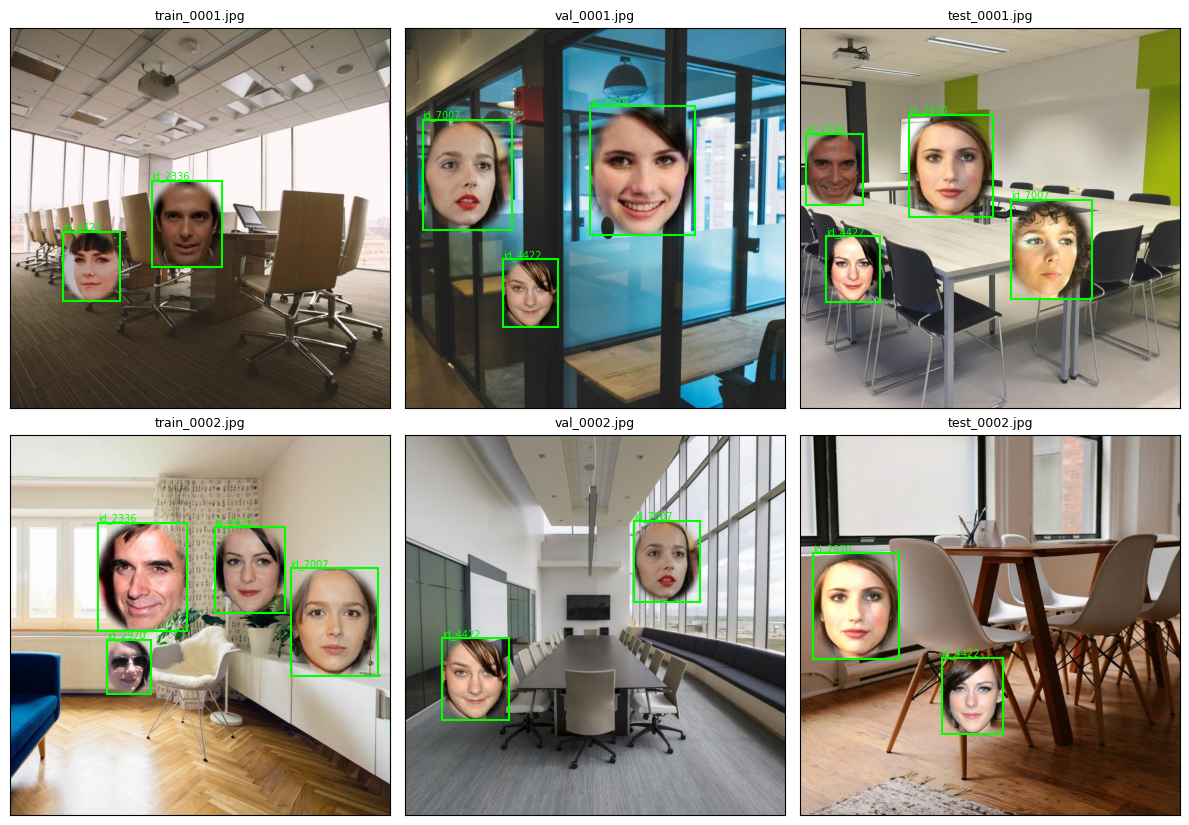

In [9]:
def draw_from_disk(ax, split, name):
    image = Image.open(syn.DET_DIR / "images" / split / f"{name}.jpg")
    ax.imshow(image)
    for line in (syn.DET_DIR / "labels" / split / f"{name}.txt").read_text().split("\n"):
        if not line:
            continue
        label, xc, yc, w, h = line.split()
        xc, yc, w, h = (float(v) * syn.IMG_SIZE for v in (xc, yc, w, h))
        ax.add_patch(plt.Rectangle((xc - w / 2, yc - h / 2), w, h,
                                   fill=False, edgecolor="lime", linewidth=1.5))
        ax.text(xc - w / 2, max(yc - h / 2 - 4, 12), syn.CLASS_NAMES[int(label)],
                color="lime", fontsize=7)
    ax.set_title(f"{name}.jpg", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

samples = [(s, f"{s}_{k:04d}") for s in syn.SPLITS for k in (1, 2)]
fig, axes = plt.subplots(2, 3, figsize=(12, 8.4))
for ax, (split, name) in zip(axes.T.flat, samples):
    draw_from_disk(ax, split, name)
fig.tight_layout()
syn.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(syn.RESULTS_DIR / "sample_annotations.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Task 2: Augmentation


---
## Task 3: Verification + Visuals
